    ## Master in Artificial Intelligence, UdC, USC, UVigo. 2025/2026
## COMPUTER VISION I

### Lab 5
### Topic 4: Image Segmentation
### Part 2: Morphological operations and region growing (1.40 pts.)

---

### Learning Objectives

In this lab, you will learn:

1. **Morphological Operations Fundamentals** - Erosion, dilation, opening, closing
2. **Structuring Elements** - How kernel shape and size affects results
3. **Optical Character Recognition (OCR) Preprocessing** - Using morphology to improve text recognition
4. **Region Growing Segmentation** - Seed-based image segmentation
5. **Morphological Post-processing** - Using morphology to clean segmentation results
6. **Example of real application** - Computing physical measurements (e.g. area, volume) from segmentations

---

#### Important: Morphological Operations Work on Binary Images

A critical concept: **morphological operations are designed for binary images** (black and white only). They work by analyzing the **structure** of foreground/background regions:

- **Erosion**: Shrinks white regions (foreground)
- **Dilation**: Expands white regions (foreground)
- **Opening**: Erosion followed by dilation - removes small white noise
- **Closing**: Dilation followed by erosion - fills small black holes

Morphology cannot directly fix grayscale degradation like stains or uneven lighting. For those problems, you need **binarization** first (converting grayscale to binary), then morphology for **post-processing**.

---

### Setup

In [1]:
# Standard imports
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

# Force reload of lab5_utils to get latest version
from lab5_utils import (
    visualize_structuring_elements,
    compare_morphological_ops,
    add_salt_noise,
    add_pepper_noise,
    apply_stroke_erosion,
    create_clean_text_image,
    # SVHN dataset functions
    load_svhn_cropped,
    prepare_svhn_for_morphology,
    # SVHN pipeline evaluation
    evaluate_morphological_pipeline,
    # Region growing and segmentation
    visualize_region_growing,
    make_similarity_criterion,
    compute_region_areas,
    merge_regions,
)

# Morphological operations from skimage

# Set random seed for reproducibility
np.random.seed(42)

# Define paths
images_path = 'images'
svhn_path = 'data/test_32x32.mat'
mri_image_path = 'data/brain_MRI_GM2.png'

print("Setup complete!")
print(f"SVHN dataset available: {os.path.exists(svhn_path)}")
print(f"MRI example data available: {os.path.exists(mri_image_path)}")

Setup complete!
SVHN dataset available: True
MRI example data available: True


---

## Morphological Operations Fundamentals

### Background: Structuring Elements

A **structuring element** (or kernel) is a small binary matrix that defines the neighborhood examined during morphological operations. The shape of the structuring element determines what structures are preserved or removed. The most common shapes are:
- **Rectangle**: General-purpose, affects all directions equally
- **Ellipse**: Smoother results, less corner artifacts
- **Cross**: Preserves horizontal and vertical structures

### Exercise 1: Create Structuring Elements

Create three 5x5 structuring elements: rectangle, ellipse, and cross.

**Hint**: Use `cv2.getStructuringElement()` with:
- `cv2.MORPH_RECT` for rectangle
- `cv2.MORPH_ELLIPSE` for ellipse  
- `cv2.MORPH_CROSS` for cross

In [2]:
def create_structuring_elements(size=5):
    """
    Create three structuring elements of the given size.
    
    Args:
        size: Size of the structuring elements (default 5)
    
    Returns:
        tuple: (kernel_rect, kernel_ellipse, kernel_cross)
    """

    kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))  # Rectangle structuring element
    kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))  # Ellipse structuring element
    kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))  # Cross structuring element
    
    return kernel_rect, kernel_ellipse, kernel_cross

Question 1 validation passed!


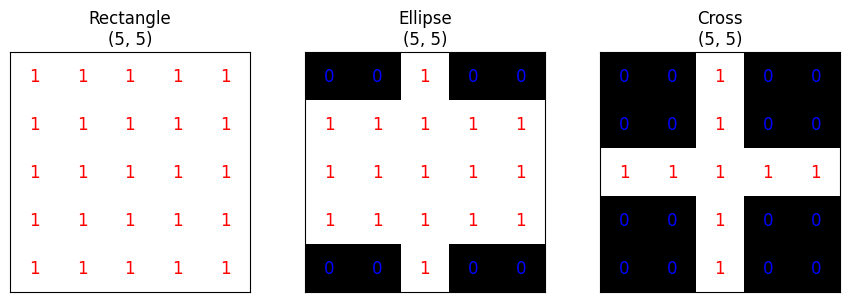

In [7]:
# Test your implementation
kernel_rect, kernel_ellipse, kernel_cross = create_structuring_elements(5)

# Validation
assert kernel_rect is not None and kernel_rect.shape == (5, 5), "Rectangle kernel should be 5x5"
assert kernel_ellipse is not None and kernel_ellipse.shape == (5, 5), "Ellipse kernel should be 5x5"
assert kernel_cross is not None and kernel_cross.shape == (5, 5), "Cross kernel should be 5x5"
assert kernel_rect.sum() == 25, "Rectangle should have all 1s"
assert kernel_cross.sum() == 9, "5x5 Cross should have 9 ones"

print("Question 1 validation passed!")

# Visualize the kernels
visualize_structuring_elements(
    [kernel_rect, kernel_ellipse, kernel_cross],
    ['Rectangle', 'Ellipse', 'Cross']
)

### Exercise 2: Erosion
Implement erosion: look for the function in Opencv that applies erosion to a binary image and complete the following `apply_erosion` function. Then, use the provided code to create a test image with text and apply erosion with different kernels. You may also want to compute new kernels (e.g. with different sizes) to better observe the impact of the kernel size.

**Erosion** shrinks white (foreground) regions by removing pixels at boundaries. A pixel remains white only if ALL pixels under the structuring element are white.

In [4]:
def apply_erosion(image, kernel, iterations=1):
    """
    Apply erosion to a binary image.
    
    Args:
        image: Binary input image
        kernel: Structuring element
        iterations: Number of times to apply erosion
    
    Returns:
        np.array: Eroded image
    """
    return cv2.erode(image, kernel, iterations=iterations)

Question 2 validation passed!
Original white pixels: 2301
After erosion (rect): 0


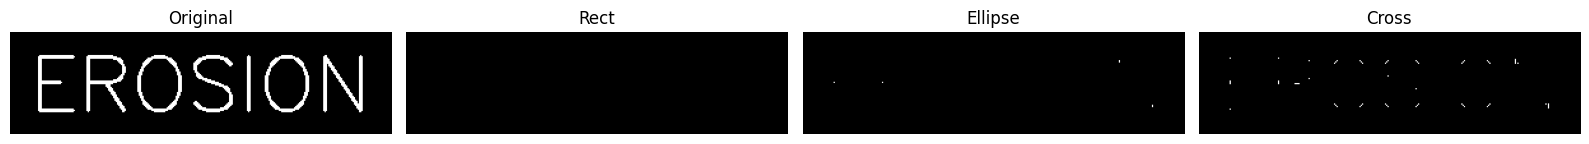

In [13]:
# Create a test image with text
test_text = create_clean_text_image("EROSION", font_size=2, image_size=(80, 300))

# Apply erosion with different kernels
eroded_rect = apply_erosion(test_text, kernel_rect)
eroded_ellipse = apply_erosion(test_text, kernel_ellipse)
eroded_cross = apply_erosion(test_text, kernel_cross)

# Validation
assert eroded_rect is not None, "apply_erosion should return an image"
assert eroded_rect.shape == test_text.shape, "Output shape should match input"
assert eroded_rect.sum() < test_text.sum(), "Erosion should reduce white pixels"

print("Question 2 validation passed!")
print(f"Original white pixels: {test_text.sum() // 255}")
print(f"After erosion (rect): {eroded_rect.sum() // 255}")

# Visualize
compare_morphological_ops(
    test_text,
    {'Rect': eroded_rect, 'Ellipse': eroded_ellipse, 'Cross': eroded_cross}
)

#### Validation Checkpoint 2

In [14]:
# Validation for Question 2
test_img = np.ones((50, 50), dtype=np.uint8) * 255
test_img[20:30, 20:30] = 0  # Black square in center
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
eroded = apply_erosion(test_img, test_kernel)

assert eroded is not None, "apply_erosion returned None"
assert eroded.shape == test_img.shape, "Output shape mismatch"
# Black region should expand after erosion (white shrinks)
assert eroded[19, 25] == 0, "Erosion should expand black region"

print("\u2713 Question 2 validation passed!")
print(f"  Original white pixels: {(test_img == 255).sum()}")
print(f"  After erosion: {(eroded == 255).sum()}")

✓ Question 2 validation passed!
  Original white pixels: 2400
  After erosion: 2356


### Exercise 3: Dilation

Implement dilation: look for the function in Opencv that applies dilation to a binary image and complete the following `apply_dilation` function. Then, use the provided code to create a test image with text and apply dilation with different kernels.

**Dilation** expands white (foreground) regions by adding pixels at boundaries. A pixel becomes white if ANY pixel under the structuring element is white.

In [15]:
def apply_dilation(image, kernel, iterations=1):
    """
    Apply dilation to a binary image.
    
    Args:
        image: Binary input image
        kernel: Structuring element
        iterations: Number of times to apply dilation
    
    Returns:
        np.array: Dilated image
    """

    return cv2.dilate(image, kernel, iterations=iterations)

Question 3 validation passed!
Original white pixels: 2098
After dilation (rect): 5396


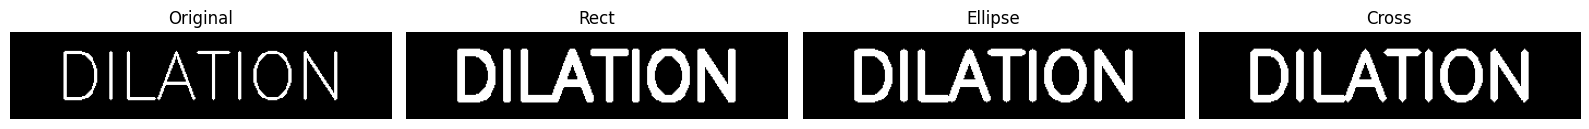

In [23]:
# Apply dilation with different kernels
test_text = create_clean_text_image("DILATION", font_size=2, image_size=(80, 350))

dilated_rect = apply_dilation(test_text, kernel_rect)
dilated_ellipse = apply_dilation(test_text, kernel_ellipse)
dilated_cross = apply_dilation(test_text, kernel_cross)

# Validation
assert dilated_rect is not None, "apply_dilation should return an image"
assert dilated_rect.shape == test_text.shape, "Output shape should match input"
assert dilated_rect.sum() > test_text.sum(), "Dilation should increase white pixels"

print("Question 3 validation passed!")
print(f"Original white pixels: {test_text.sum() // 255}")
print(f"After dilation (rect): {dilated_rect.sum() // 255}")

# Visualize
compare_morphological_ops(
    test_text,
    {'Rect': dilated_rect, 'Ellipse': dilated_ellipse, 'Cross': dilated_cross}
)

#### Validation Checkpoint 3

In [17]:
# Validation for Question 3
test_img = np.zeros((50, 50), dtype=np.uint8)
test_img[20:30, 20:30] = 255  # White square in center
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
dilated = apply_dilation(test_img, test_kernel)

assert dilated is not None, "apply_dilation returned None"
assert dilated.shape == test_img.shape, "Output shape mismatch"
# White region should expand after dilation
assert dilated[19, 25] == 255, "Dilation should expand white region"

print("\u2713 Question 3 validation passed!")
print(f"  Original white pixels: {(test_img == 255).sum()}")
print(f"  After dilation: {(dilated == 255).sum()}")

✓ Question 3 validation passed!
  Original white pixels: 100
  After dilation: 144


### Exercise 4: Opening and Closing

Implement opening and closing: look for the functions in Opencv that apply opening and closing to a binary image and complete the following `apply_opening` and `apply_closing` functions.
Then, use the provided code to create test images with text. This time we will also add salt or pepper noise: https://en.wikipedia.org/wiki/Salt-and-pepper_noise


- **Opening** = Erosion followed by Dilation (removes small white noise)
- **Closing** = Dilation followed by Erosion (fills small black holes)

**Hint**: You can use `cv2.morphologyEx()` with `cv2.MORPH_OPEN` or `cv2.MORPH_CLOSE`

In [24]:
def apply_opening(image, kernel):
    """
    Apply morphological opening (erosion then dilation).
    Removes small white noise from binary images.
    
    Args:
        image: Binary input image
        kernel: Structuring element
    
    Returns:
        np.array: Opened image
    """

    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)


def apply_closing(image, kernel):
    """
    Apply morphological closing (dilation then erosion).
    Fills small black holes in binary images.
    
    Args:
        image: Binary input image
        kernel: Structuring element
    
    Returns:
        np.array: Closed image
    """

    return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

Question 4 validation passed!


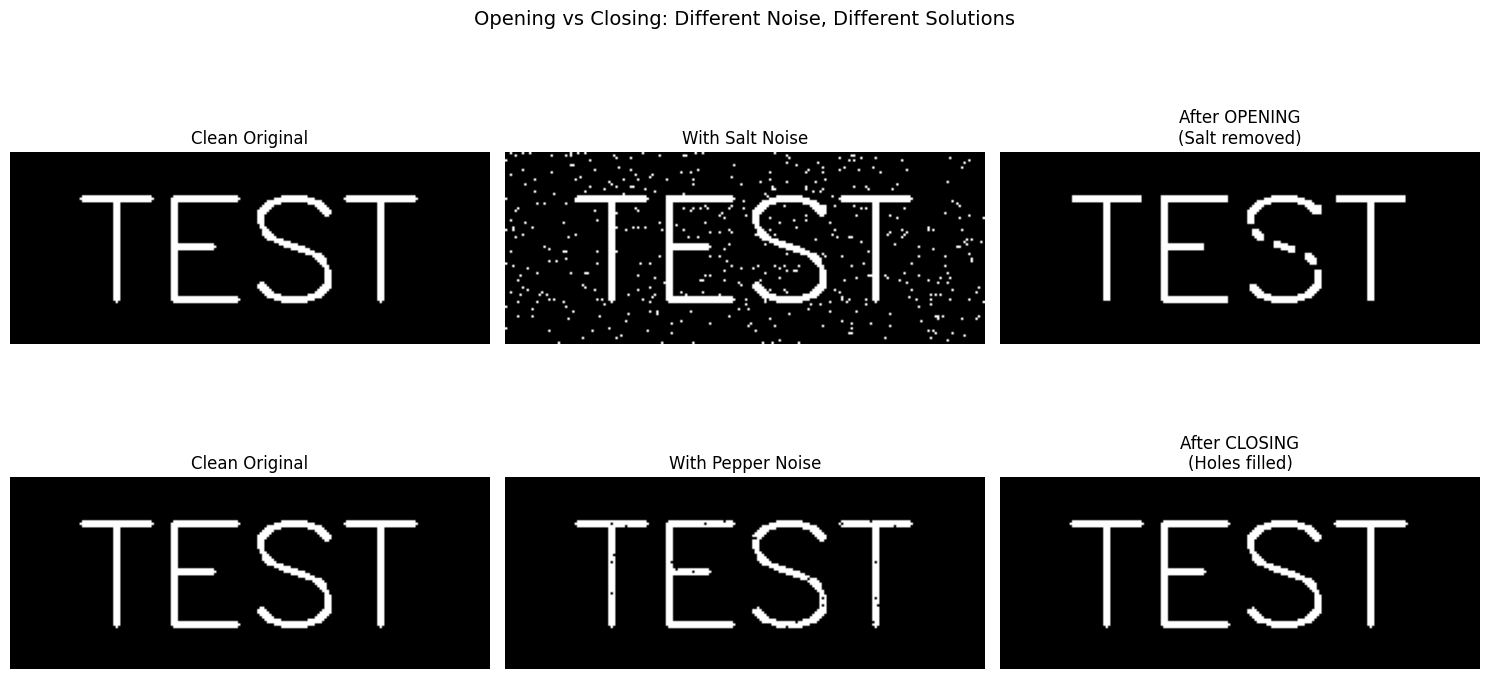

In [25]:
# Create images with different noise types
clean_text = create_clean_text_image("TEST", font_size=2, image_size=(80, 200))
salt_noisy = add_salt_noise(clean_text, ratio=0.03)  # White noise in background
pepper_noisy = add_pepper_noise(clean_text, ratio=0.03)  # Black holes in text

kernel_3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Apply opening to remove salt noise
opened = apply_opening(salt_noisy, kernel_3)

# Apply closing to fill pepper holes
closed = apply_closing(pepper_noisy, kernel_3)

# Validation
assert opened is not None, "apply_opening should return an image"
assert closed is not None, "apply_closing should return an image"

# Opening should reduce white pixels (removes salt noise)
assert opened.sum() < salt_noisy.sum(), "Opening should remove salt noise"
# Closing should increase white pixels (fills pepper holes)
assert closed.sum() > pepper_noisy.sum(), "Closing should fill pepper holes"

print("Question 4 validation passed!")

# Visualize the effects
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(clean_text, cmap='gray')
axes[0, 0].set_title('Clean Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(salt_noisy, cmap='gray')
axes[0, 1].set_title('With Salt Noise')
axes[0, 1].axis('off')

axes[0, 2].imshow(opened, cmap='gray')
axes[0, 2].set_title('After OPENING\n(Salt removed)')
axes[0, 2].axis('off')

axes[1, 0].imshow(clean_text, cmap='gray')
axes[1, 0].set_title('Clean Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(pepper_noisy, cmap='gray')
axes[1, 1].set_title('With Pepper Noise')
axes[1, 1].axis('off')

axes[1, 2].imshow(closed, cmap='gray')
axes[1, 2].set_title('After CLOSING\n(Holes filled)')
axes[1, 2].axis('off')

plt.suptitle('Opening vs Closing: Different Noise, Different Solutions', fontsize=14)
plt.tight_layout()
plt.show()

#### Validation Checkpoint 4

In [26]:
# Validation for Question 4
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Test opening removes small white noise
test_open = np.zeros((50, 50), dtype=np.uint8)
test_open[25, 25] = 255  # Single white pixel (noise)
opened_test = apply_opening(test_open, test_kernel)
assert opened_test is not None, "apply_opening returned None"
assert opened_test[25, 25] == 0, "Opening should remove isolated white pixel"

# Test closing fills small black holes
test_close = np.ones((50, 50), dtype=np.uint8) * 255
test_close[25, 25] = 0  # Single black pixel (hole)
closed_test = apply_closing(test_close, test_kernel)
assert closed_test is not None, "apply_closing returned None"
assert closed_test[25, 25] == 255, "Closing should fill isolated black pixel"

print("\u2713 Question 4 validation passed!")
print("  Opening correctly removes small white noise")
print("  Closing correctly fills small black holes")

✓ Question 4 validation passed!
  Opening correctly removes small white noise
  Closing correctly fills small black holes


### Exercise 5 (0.20pts):
- Explain and visually show with your own examples what is the effect of using different kernel shapes and sizes.
- Implement a method to better visualize which areas of the image changed after applying these operations, other than having to compare two images simultaneously.



1. Making the kernels bigger will make that the morphological operations have a greater effect on the image. For erosion it will erase more of the foreground while for Dilation it will have bigger boundaries. The shape impacts the end result. The rectangle matrix results in a more blocky image while the elipse rounds out the edgse more. 

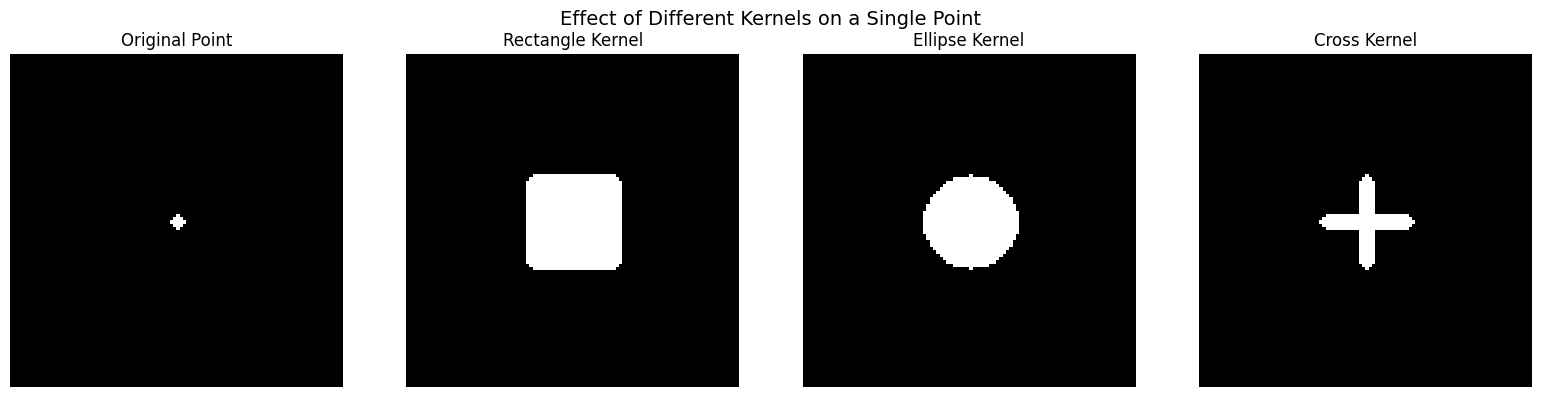

In [31]:
shape_img = np.zeros((100, 100), dtype=np.uint8)
cv2.circle(shape_img, (50, 50), 2, 255, -1) # Small dot

kernel_rect, kernel_ellipse, kernel_cross = create_structuring_elements(25)

res_rect = apply_dilation(shape_img, kernel_rect)
res_ellip = apply_dilation(shape_img, kernel_ellipse)
res_cross = apply_dilation(shape_img, kernel_cross)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(shape_img, cmap='gray')
axes[0].set_title('Original Point')
axes[0].axis('off')

axes[1].imshow(res_rect, cmap='gray')
axes[1].set_title('Rectangle Kernel')
axes[1].axis('off')

axes[2].imshow(res_ellip, cmap='gray')
axes[2].set_title('Ellipse Kernel')
axes[2].axis('off')

axes[3].imshow(res_cross, cmap='gray')
axes[3].set_title('Cross Kernel')
axes[3].axis('off')

plt.suptitle("Effect of Different Kernels on a Single Point", fontsize=14)
plt.tight_layout()
plt.show()

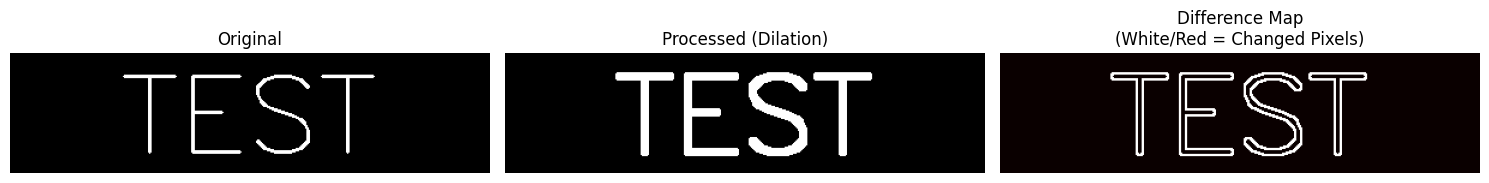

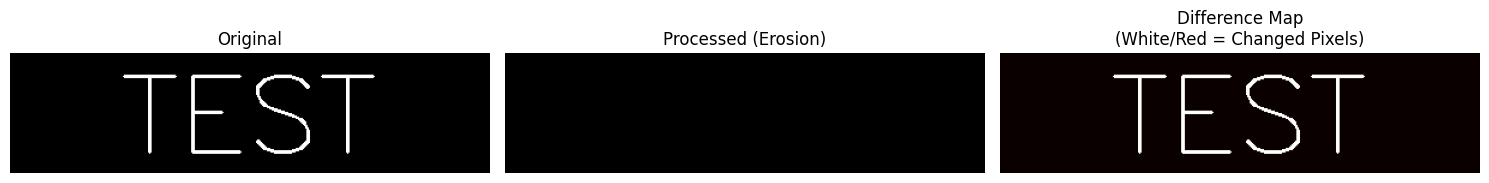

In [33]:
def visualize_changes(original, processed, title="Morphological Operation"):
    """
    Visualizes the specific pixels that changed after an operation.
    
    Args:
        original: The original binary image
        processed: The image after morphological operation
        title: Title for the plot
    """
    diff = cv2.absdiff(original, processed)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title(f'Processed ({title})')
    axes[1].axis('off')
    
    axes[2].imshow(diff, cmap='hot') 
    axes[2].set_title('Difference Map\n(White/Red = Changed Pixels)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

test_img = create_clean_text_image("TEST", font_size=3)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
dilated_img = apply_dilation(test_img, kernel)

eroded_img = apply_erosion(test_img, kernel)

visualize_changes(test_img, dilated_img, "Dilation")

visualize_changes(test_img, eroded_img, "Erosion")

---

## OCR with Morphological Preprocessing

**OCR (Optical Character Recognition)** is a technology that converts images containing text into machine-readable text. When you scan a document or take a photo of a sign, OCR algorithms analyze the image to identify and extract the text characters.

**How OCR works (simplified):**
1. **Preprocessing** - Clean up the image (binarization, noise removal)
2. **Character segmentation** - Identify individual characters
3. **Feature extraction** - Analyze character shapes and patterns
4. **Classification** - Match features to known characters using trained models

**Why image quality matters:**
OCR models are typically trained on clean, high-contrast text. When images are degraded by noise, blur, or poor lighting, the extracted features become unreliable and recognition accuracy drops significantly.

**The morphology connection:**
Since OCR works on binary images (black text on white background), morphological operations are ideal for preprocessing since, as we have already seen in this lab, they can:

1. **Remove noise** that confuses character recognition.
2. **Repair broken strokes** that split characters.
3. **Separate touching characters** that merge incorrectly.


### Real-World Data: SVHN Dataset

Instead of synthetic text, we'll use the **SVHN (Street View House Numbers)** dataset - real photographs of house number digits captured from Google Street View. This provides:

- Real-world lighting variations
- Natural image noise
- Authentic digit appearances
- Known ground truth labels for validation

Next, we will visualize a few examples (first row) and their binarized version (second row):

Loaded 10 SVHN images
Labels: [2, 1, 3, 0, 2, 5, 0, 1, 7, 1]


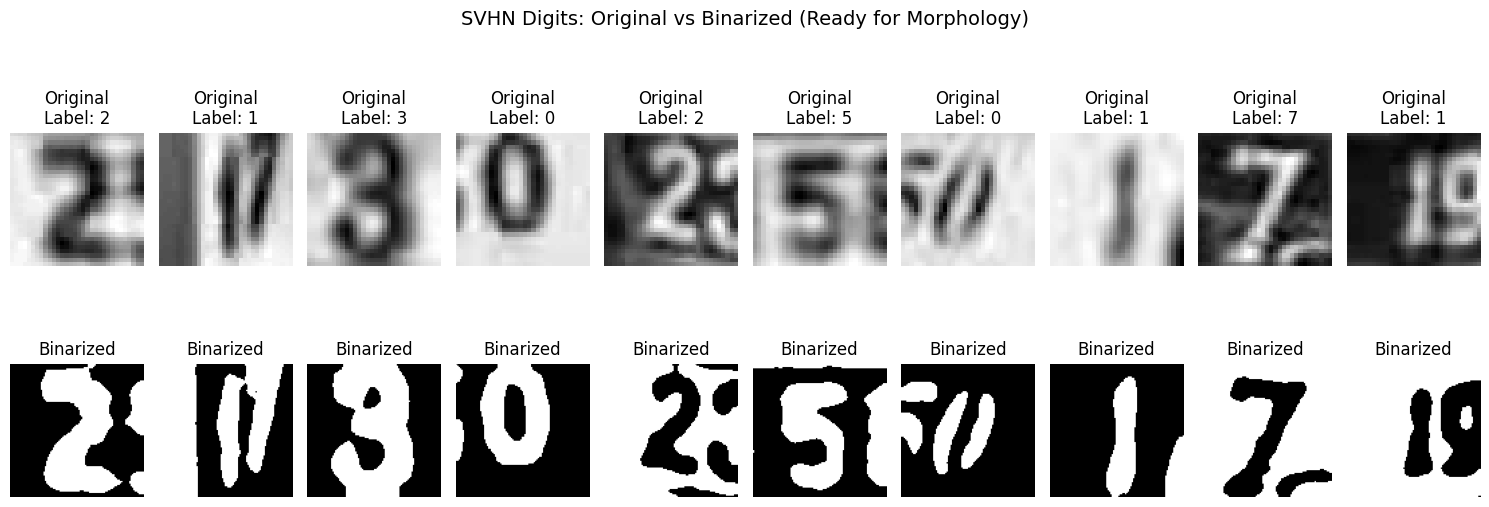

In [61]:
# Load SVHN dataset - real street number digits
svhn_images, svhn_labels = load_svhn_cropped(svhn_path, n_samples=10, seed=42)

print(f"Loaded {len(svhn_images)} SVHN images")
print(f"Labels: {svhn_labels}")

# Display original SVHN images
#visualize_svhn_samples(svhn_images, svhn_labels, title='SVHN Dataset: Real Street Number Digits')

# Prepare for morphological operations (resize and binarize)
binary_digits = [prepare_svhn_for_morphology(img, target_size=(100, 100)) for img in svhn_images]

# Show binarized versions
fig, axes = plt.subplots(2, 10, figsize=(15, 6))
for i in range(10):
    axes[0, i].imshow(svhn_images[i], cmap='gray')
    axes[0, i].set_title(f'Original\nLabel: {svhn_labels[i]}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(binary_digits[i], cmap='gray')
    axes[1, i].set_title('Binarized')
    axes[1, i].axis('off')

plt.suptitle('SVHN Digits: Original vs Binarized (Ready for Morphology)', fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 6 (0.5 pts): OCR Preprocessing Pipeline

In this part of the lab we will:
1. Apply synthetic degradation (salt/pepper noise; broken strokes; touching characters) to the SVHN digits and then,
2. Apply the most suitable morphological operations to restore them. The goal is to restore the degraded digit so OCR can recognize it.

First, think about the correct matching between the **degradation type** and the **correct morphological fix** and complete the following table:

| Degradation | Morphological Fix |
|-------------|-------------------|
| Salt noise (white spots in background) | Opening           |
| Pepper noise (black holes in text) | Closing            |
| Broken strokes (thin/disconnected) | Dilation           |
| Touching characters | Erotion           |

**HINT:** Would it be possible to create broken strokes and touching parameters using the morphological operations seen before?

Then, complete the following code to apply the most suitable morphological operation to restore each of the suggested image degradation types:

In [76]:
def preprocess_for_ocr(image, degradation_type='combined'):
    """
    Apply morphological preprocessing to improve OCR results.
    
    Args:
        image: Binary input image (white text on black background)
        degradation_type: One of 'salt', 'pepper', 'eroded', 'combined'
    
    Returns:
        np.array: Preprocessed binary image
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    result = image  # Default: return original if unknown type
    
    if degradation_type == 'salt':
        # Salt noise = white spots in background
        result = apply_opening(image, kernel)
        
    elif degradation_type == 'pepper':
        # Pepper noise = black holes in text
        result = apply_closing(image, kernel)
        
    elif degradation_type == 'eroded':
        # Eroded strokes = thin/broken text
        result = apply_dilation(image, kernel)
        
    elif degradation_type == 'combined':
        # Combined degradation = multiple issues
        partial_result = apply_closing(image, kernel)
        partial_result = apply_opening(partial_result, kernel)
        result = apply_dilation(partial_result, kernel)
    
    return result

Now try the full pipeline **with several examples** (i.e. different degraded versions, different samples from the dataset, etc.) and explain what do you observe. Will the restoration always work?

Testing with SVHN digit: 7


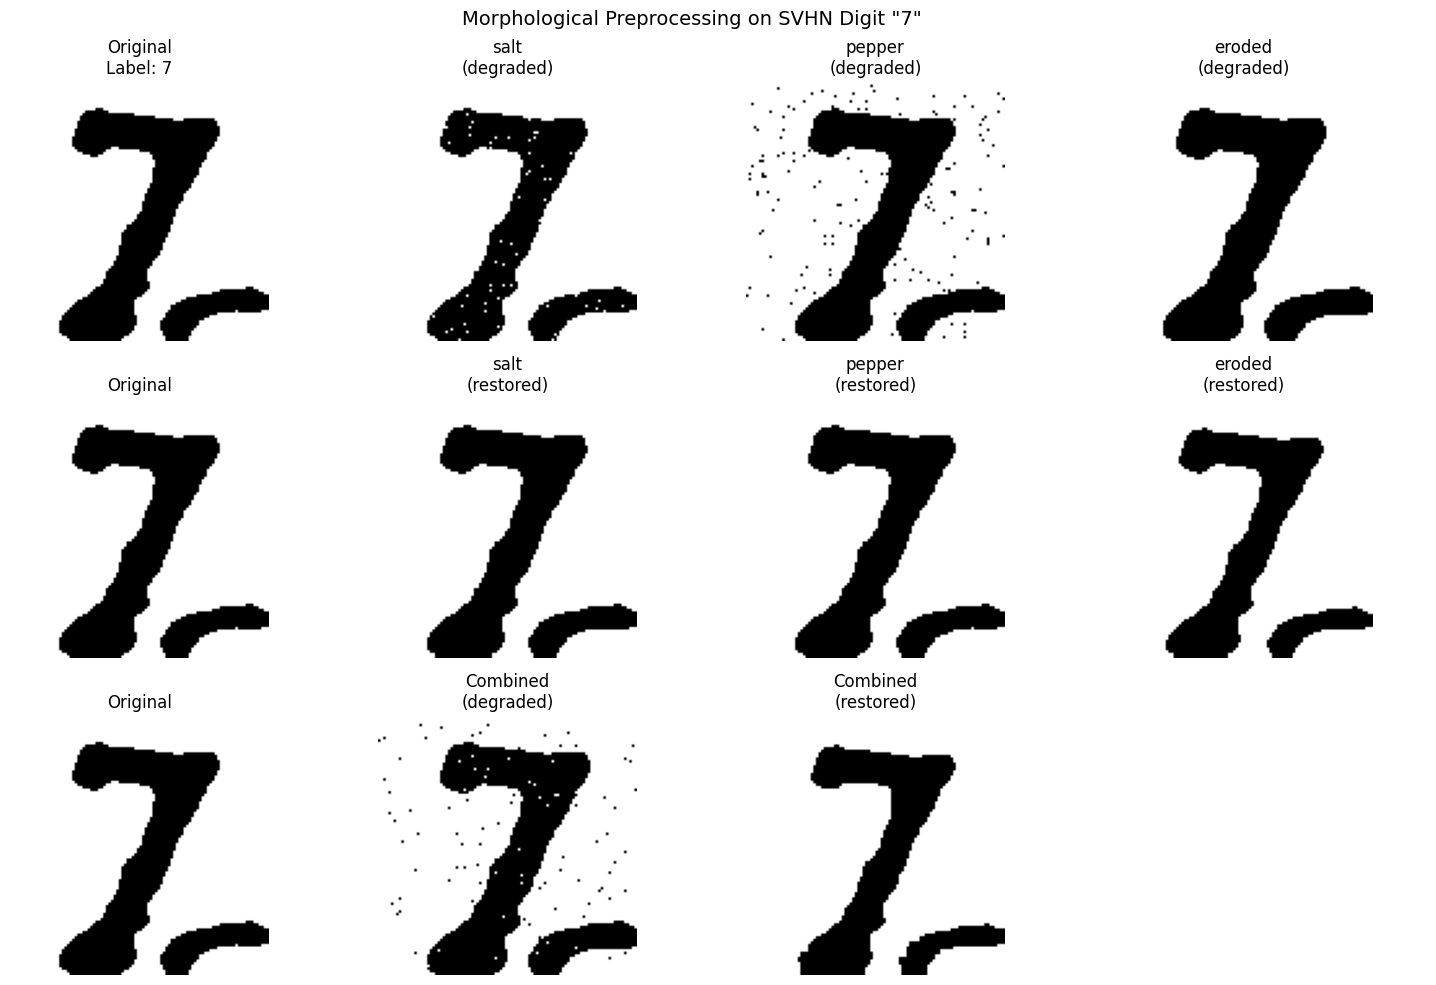

In [62]:
# Test preprocessing on SVHN digits with synthetic degradation
# Use the first binarized digit as our test image
test_digit = binary_digits[8]
ground_truth_label = str(svhn_labels[8])

print(f"Testing with SVHN digit: {ground_truth_label}")

#Create degraded versions
degraded = {
    'salt': add_salt_noise(test_digit, 0.02),
    'pepper': add_pepper_noise(test_digit, 0.02),
    'eroded': apply_stroke_erosion(test_digit, 2, 1),
    'combined': add_salt_noise(add_pepper_noise(apply_stroke_erosion(test_digit, 2, 1), 0.01), 0.01)
}


# Apply preprocessing
restored = {}
for dtype, img in degraded.items():
    restored[dtype] = preprocess_for_ocr(img, dtype)

# # Validation
# for dtype in degraded:
#     assert restored[dtype] is not None, f"Preprocessing for {dtype} should return an image"
#
# print("Question 5 validation passed!")

# Visualize before/after
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

# Row 0: Original and degraded
axes[0, 0].imshow(test_digit, cmap='gray')
axes[0, 0].set_title(f'Original\nLabel: {ground_truth_label}')
axes[0, 0].axis('off')

for idx, dtype in enumerate(list(degraded.keys())[:3], start=1):
    axes[0, idx].imshow(degraded[dtype], cmap='gray')
    axes[0, idx].set_title(f'{dtype}\n(degraded)')
    axes[0, idx].axis('off')

# Row 1: Restored versions
axes[1, 0].imshow(test_digit, cmap='gray')
axes[1, 0].set_title('Original')
axes[1, 0].axis('off')

for idx, dtype in enumerate(list(restored.keys())[:3], start=1):
    axes[1, idx].imshow(restored[dtype], cmap='gray')
    axes[1, idx].set_title(f'{dtype}\n(restored)')
    axes[1, idx].axis('off')

# Row 2: Combined case
axes[2, 0].imshow(test_digit, cmap='gray')
axes[2, 0].set_title('Original')
axes[2, 0].axis('off')

axes[2, 1].imshow(degraded['combined'], cmap='gray')
axes[2, 1].set_title('Combined\n(degraded)')
axes[2, 1].axis('off')

axes[2, 2].imshow(restored['combined'], cmap='gray')
axes[2, 2].set_title('Combined\n(restored)')
axes[2, 2].axis('off')

axes[2, 3].axis('off')

plt.suptitle(f'Morphological Preprocessing on SVHN Digit "{ground_truth_label}"', fontsize=14)
plt.tight_layout()
plt.show()

**OCR Testing with EasyOCR:**
Now let's use EasyOCR (https://github.com/JaidedAI/EasyOCR) to see if preprocessing actually improves text recognition.

First, initialize EasyOCR:

In [63]:
# Initialize EasyOCR (downloads models on first run)
#import easyocr
try:
    import easyocr
    reader = easyocr.Reader(['en'], gpu=False, verbose=False)
    OCR_AVAILABLE = True
    print("EasyOCR initialized successfully!")
except ImportError:
    print("EasyOCR not installed. Run: pip install easyocr")
    OCR_AVAILABLE = False

def extract_text(image):
    """
    Extract text from image using EasyOCR.
    
    Args:
        image: Grayscale or binary image
    
    Returns:
        str: Extracted text
    """
    if not OCR_AVAILABLE:
        return "[OCR not available]"
    
    # EasyOCR expects images in a certain format
    if len(image.shape) == 2:
        # Already grayscale
        img = image
    else:
        img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    results = reader.readtext(img)
    text = ' '.join([r[1] for r in results])
    return text.strip()

EasyOCR initialized successfully!


Now, test it on the previously computed degraded and restored digits. The following code will only highlight cases where morphology had an effect (positive or negative) in recognizing the digits.
Go back and generate different degraded + restored images and then run the following code to see the impact of these operations in the identification of the true digits. Briefly summarize what do you observe. Is there a degradation that is harder / easier to recover?

In [64]:
# Test OCR on degraded vs restored SVHN digits
# Only show cases where morphology had an EFFECT (positive or negative)
if OCR_AVAILABLE:
    print(f"Ground truth label: '{ground_truth_label}'")
    print("-" * 50)
    print("Showing cases where morphology CHANGED the OCR result:")
    print()
    
    effect_count = 0
    for dtype in degraded.keys():
        text_degraded = extract_text(degraded[dtype])
        text_restored = extract_text(restored[dtype])
        
        # Only show if morphology changed the result
        if text_degraded != text_restored:
            effect_count += 1
            degraded_correct = text_degraded == ground_truth_label
            restored_correct = text_restored == ground_truth_label
            
            print(f"{dtype.upper()} degradation:")
            print(f"  Before: '{text_degraded}' {'[correct]' if degraded_correct else '[incorrect]'}")
            print(f"  After:  '{text_restored}' {'[correct]' if restored_correct else '[incorrect]'}")
            
            if restored_correct and not degraded_correct:
                print(f"  -> IMPROVED! Morphology fixed the recognition")
            elif degraded_correct and not restored_correct:
                print(f"  -> WORSE! Morphology damaged the digit")
            else:
                print(f"  -> Changed (both incorrect)")
            print()
    
    if effect_count == 0:
        print("No changes detected - morphology had no effect on any case")
    else:
        print(f"Morphology changed {effect_count}/{len(degraded)} cases")
else:
    print("Skipping OCR test - EasyOCR not installed")
    print("To enable OCR testing, run: pip install easyocr")

Ground truth label: '7'
--------------------------------------------------
Showing cases where morphology CHANGED the OCR result:

No changes detected - morphology had no effect on any case


I tried with different numbers and changing the size of the kernel. but couldnt get to detect some changes.
Fixing the salt and pepper seems to be easier, both morphologies seem to be fixed after applying the kernels. But fixing the broken numbers or extra parts is harder to achieve. My guess is this is impeding the detection to occur, the processing is not hard enough to fix this issues.

### Exercise 7 (0.15 pts): Comprehensive Morphological Pipeline Evaluation

Now it's time to put your `preprocess_for_ocr` function to the test on a **larger dataset**. The `evaluate_morphological_pipeline` function will:

1. Load multiple SVHN digits
2. Apply various degradation types (salt, pepper, erosion, combined). **This is fixed now**.
3. Run your preprocessing pipeline. **Run your `preprocess_for_ocr` function and further modify if needed.**
4. Use OCR to measure digit recognition accuracy before and after your preprocessing

Your goal is to achieve **overall improvement > 0%**  (the higher, the better), showing that your morphological pipeline genuinely helps OCR recognize degraded digits better.

**Challenge levels:**
- Beginner: Any positive improvement
- Intermediate: > 5% improvement
- Advanced: > 10% improvement

Evaluating your morphological pipeline on SVHN digits...
This will test your preprocess_for_ocr function against real OCR.
Examples shown are cases where morphology CHANGED the OCR result.

Loaded 15 SVHN digits for evaluation
Testing degradation types: salt, pepper, eroded, combined
------------------------------------------------------------

MORPHOLOGICAL PIPELINE EVALUATION RESULTS

Degradation  | Before     | After      | Change    
--------------------------------------------------
salt         |     40.0% |     46.7% | +    6.7%
pepper       |     33.3% |     40.0% | +    6.7%
eroded       |     33.3% |     40.0% | +    6.7%
combined     |     40.0% |     46.7% | +    6.7%
--------------------------------------------------
OVERALL      |     36.7% |     43.3% | +    6.7%

Pipeline shows significant improvement!


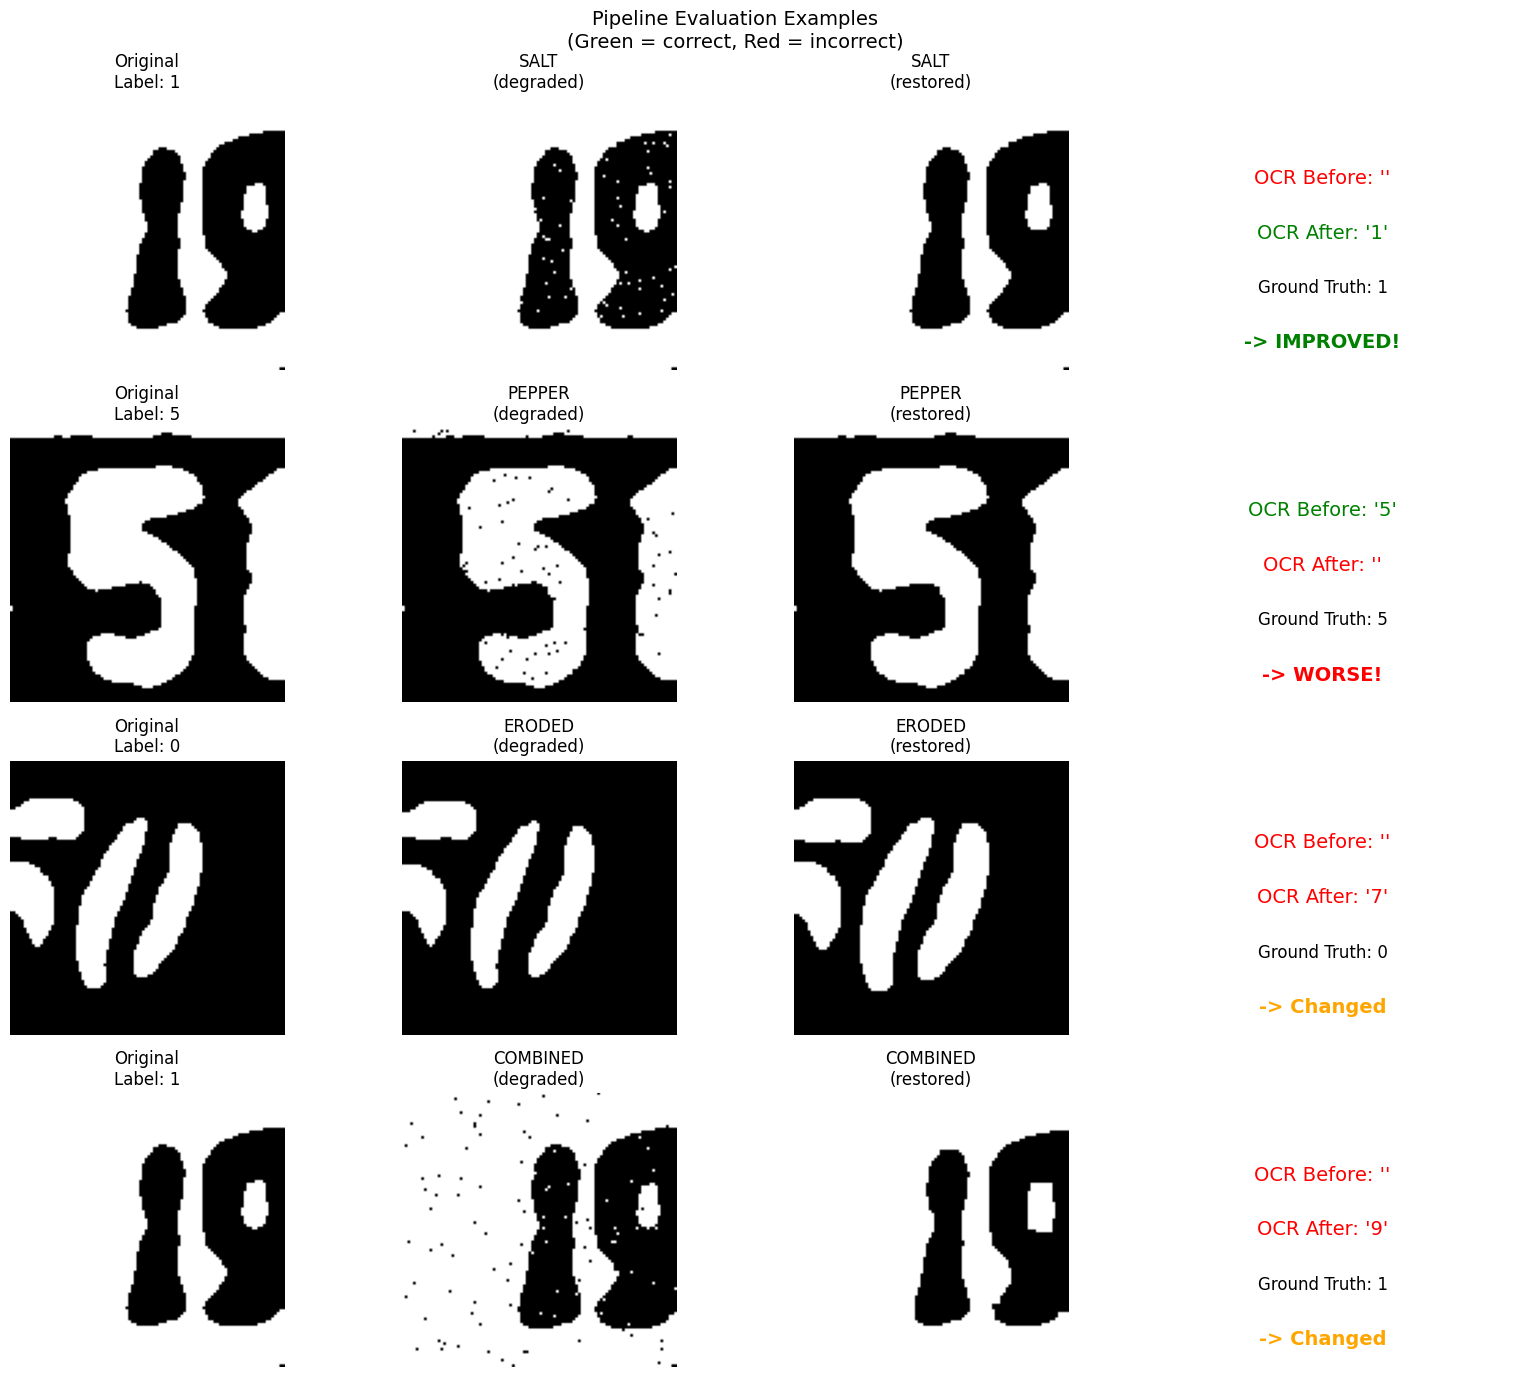


GOOD! Your pipeline shows solid improvement (>5%).


In [77]:
# Evaluate your preprocess_for_ocr function on the full SVHN test set
# This will take about 30-60 seconds depending on your machine

if OCR_AVAILABLE:
    print("Evaluating your morphological pipeline on SVHN digits...")
    print("This will test your preprocess_for_ocr function against real OCR.")
    print("Examples shown are cases where morphology CHANGED the OCR result.")
    print()
    
    # Run the evaluation
    results = evaluate_morphological_pipeline(
        pipeline_func=preprocess_for_ocr,
        svhn_path=svhn_path,
        n_samples=15,
        degradation_ratio=0.02,
        verbose=True,
        show_examples=True,
        show_only_changed=True  # Only show examples where morphology had an effect
    )
    
    if results is not None:
        improvement = results['overall_improvement']
        
        print("\n" + "=" * 60)
        if improvement > 10:
            print("EXCELLENT! Your pipeline shows significant improvement (>10%)!")
        elif improvement > 5:
            print("GOOD! Your pipeline shows solid improvement (>5%).")
        elif improvement > 0:
            print("Your pipeline shows some improvement.")
        else:
            print("Your pipeline needs work - accuracy decreased or stayed the same.")
        print("=" * 60)
else:
    print("OCR not available. Install EasyOCR to run this evaluation:")
    print("  pip install easyocr")

---
## Pipeline for real medical image segmentation

In this part of the lab we are asked to compute the area of the gray matter from a 2D MRI scan. We will do it in 3 steps:
1. Apply the region growing algorithm to segment different areas of the brain. We will try to at least separate: gray matter, left and right brain ventricles, and skull.
2. Apply morphological operation to clean the segmentation (in this case, with several labels, one for each region).
3. Use the pixel size to compute the area of the gray matter. This (it would be better to compute the volume) may be indicative of cognitive impairment.


**Region growing** is a seed-based segmentation algorithm that:
1. Starts from user-defined seed points.
2. Iteratively adds neighboring pixels that are "similar" to the region.
3. Stops when no more similar pixels can be added.

The similarity criterion typically compares pixel intensity to the region mean:
$$C(v, i) = |I[v] - \mu_i| \leq \tau$$

Where:
- $I[v]$ is the pixel intensity at position $v$
- $\mu_i$ is the mean intensity of region $i$
- $\tau$ is the similarity threshold

We first load the data:

In [ ]:
brain_mri = cv2.imread('data/brain_MRI_GM2.png', cv2.IMREAD_GRAYSCALE)     # original image for reference

if brain_mri is None:
    print(f"Could not load image, check path")
else:
    mri_normalized = brain_mri.astype(np.float64) / 255.0
    
    # Visualize
    plt.figure(figsize=(8, 6))
    plt.imshow(mri_normalized, cmap='gray')
    plt.title(f'Brain MRI example')
    plt.colorbar(label='Normalized Intensity')
    plt.show()

### Exercise 8 (0.15 pts): Region Growing Segmentation

Apply region growing segmentation to the MRI slice. The final objective is to calculate the area of the gray matter, so we need to pay special attention to this area. At this point we will try to at least separate:
- gray matter
- the 2 brain ventricles (gray structures in the center of the image)
- the skull (outer white contour)

**Task**: using the following code **define appropriate seed points** for different brain structures and run the segmentation. **Tune the parameters tau and max_iterations** to get approximate correct segmentations.

When the algorithm finishes you will be able to visualize the iterative region growing process.

**Hints**:
- Coordinates are (row, col) - row is Y (vertical), col is X (horizontal)
- Click on the image above to identify approximate coordinates
- Start with a single seed, then try multiple seeds (one per region)

In [ ]:
# Define seed points - adjust these based on the structures you want to segment
# Format: ((row1, col1), (row2, col2), ...)
seed_points = ((60,128),)

# Create similarity criterion
# tau controls how similar pixels must be to join the region
# Lower tau = stricter, smaller regions
# Higher tau = looser, larger regions
tau = 0.08  # Adjust this value

criterion = make_similarity_criterion(mri_normalized, tau=tau)

# Run region growing with GIF visualization
segmentation = visualize_region_growing(
    mri_normalized,
    seed_points,
    criterion,
    frame_step=1000,  # Capture frame every 1000 iterations
    output_path="region_growing_mri.gif",
    fps=5,
    max_iterations=30000,
    verbose=True
)

#### Validation Checkpoint 8

In [ ]:
# Validation for Question 8
assert segmentation is not None, "Region growing returned None"
assert segmentation.shape == mri_normalized.shape, "Segmentation shape mismatch"
unique_regions = np.unique(segmentation[segmentation >= 0])
assert len(unique_regions) >= 1, "No regions segmented"

print("\u2713 Question 8 validation passed!")
print(f"  Segmentation shape: {segmentation.shape}")
print(f"  Number of regions: {len(unique_regions)}")
print(f"  Region IDs: {list(unique_regions)}")

### Exercise 9 (0.20 pts): segmentation post-processing and area calculation.

Hopefully you would have computed an approximate segmentation of the different structures. With respect to the gray matter, due to its own intensity heterogeneity (which has been deliberately exaggerated in the image) the result is not optimal (with many small black dots). We will now **apply morphological operations to clean the masks** obtained before.
Think about the most appropriate operation or set of operations, bearing in mind that our aim is to eliminate the small black dots while keeping the brain sulci (folds) unmodified.

In [ ]:
# Keep only the gray matter (you may need to modify the label):
gm_mask = (segmentation == 2).astype(np.uint8) * 255

## MORPHOLOGICAL OPERATIONS

## YOUR CODE HERE
#gm_post = ...

# Visualize before and after. You may also want to visualize other intermediate outputs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(segmentation, cmap='nipy_spectral')
axes[0].set_title('Original Segmentation')
axes[0].axis('off')

# axes[1].imshow(gm_post, cmap='nipy_spectral')
# axes[1].set_title('After morphological postprocessing')
# axes[1].axis('off')

plt.tight_layout()
plt.show()


Given that each pixel represents a physical area of **0.22 mm²** (0.4688mm × 0.4688mm pixel spacing), calculate the area of the gray matter:

In [ ]:
# Pixel spacing for axial slices in this case
PIXEL_AREA_MM2 = 0.4688 * 0.4688

def calculate_region_area(segmentation, region_id, pixel_area_mm2):
    """
    Calculate the physical area of a specific region.
    
    Args:
        segmentation: Label array from region growing
        region_id: ID of the region to measure
        pixel_area_mm2: Area of each pixel in mm²
    
    Returns:
        float: Area in mm²
    """

   # YOUR CODE HERE
    # Count pixels with the given region_id and multiply by pixel_area_mm2
    return None

#print(calculate_region_area(gm_post, 255, PIXEL_AREA_MM2) / 100, 'cm2')

### Exercise 10 (0.20 pts): Multi-Seed Segmentation and Area Merging

To finish this lab we go back to the region growing algorithm. As you may have observed, a single seed point often cannot capture an entire anatomical structure because:
- The structure may have varying contrast/intensity
- Different parts may be separated by boundaries
- The similarity threshold may be too strict

And in any case, the segmentation would take longer than if we use multiple seeds for the same region.
Now we are going to use multiple seed points and merge regions that belong to the same structure.

**Task**:
1. Place at least 3 seeds in different parts of the gray matter.
2. Run the segmentation.
3. Visually identify which regions correspond to ventricular tissue.
4. **Merge** those regions and calculate the combined area.

Remember that you should always tune the **tau** and **max_iterations** parameters.

In [ ]:
## SELECT PROPER SEEDS:
multi_seeds = (
    (60, 120),   # Seed 0 - adjust location
    (60, 140),   # Seed 1 - adjust location
    (70, 130),   # Seed 2 - adjust location
#    (p1, p2),
)

# Use same tau or adjust
criterion_multi = make_similarity_criterion(mri_normalized, tau=0.08)   # conservative tau, slow, cannot cross subtle limits
#criterion_multi = make_similarity_criterion(mri_normalized, tau=0.15)    # allows crossing a few more borders...

# Run segmentation
multi_seg = visualize_region_growing(
    mri_normalized,
    multi_seeds,
    criterion_multi,
    frame_step=1000,
    output_path="region_growing_multi_seed.gif",
    fps=5,
    max_iterations=30000,
    verbose=True
)

In [ ]:
# Analyze the multi-seed segmentation
if multi_seg is not None:
    # Show each region's area
    areas = compute_region_areas(multi_seg, PIXEL_AREA_MM2)

    print("Individual region areas:")
    for rid, area in areas.items():
        print(f"  Region {rid} (seed at {multi_seeds[rid]}): {area:.2f} mm²")

    # Visualize to help identify which regions to merge
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(mri_normalized, cmap='gray')
    axes[0].set_title('Original with Seed Points')
    for i, s in enumerate(multi_seeds):
        axes[0].plot(s[1], s[0], 'o', markersize=10, label=f'Seed {i}')
    axes[0].legend()
    axes[0].axis('off')

    axes[1].imshow(multi_seg, cmap='nipy_spectral')
    axes[1].set_title('Multi-Seed Segmentation\n(Different colors = different regions)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Merge regions that belong to the same anatomical structure
# Based on your visual analysis, which regions should be merged?

labels_to_merge = [0, 1]  # YOUR ANSWER: which region IDs to merge?

# Merge the regions, THE OTHERS REMAIN THE SAME
merged_seg = merge_regions(multi_seg, labels_to_merge)

# Calculate combined area
merged_areas = compute_region_areas(merged_seg, PIXEL_AREA_MM2)

print("\n" + "=" * 50)
print("MERGED REGION AREAS")
print("=" * 50)
print(f"Merged labels: {labels_to_merge}")
print()
for rid, area in merged_areas.items():
    print(f"Region {rid}: {area:.2f} mm²")
print("=" * 50)

# Visualize merged result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(multi_seg, cmap='nipy_spectral')
axes[0].set_title('Before Merging')
axes[0].axis('off')

axes[1].imshow(merged_seg, cmap='nipy_spectral')
axes[1].set_title('After Merging')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Compute the area
# YOUR CODE HERE